In [18]:
from google.colab import files
uploaded = files.upload()

Saving Customers_Fakedata.csv to Customers_Fakedata (1).csv


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
custom_colors = ["#7851A9", "#C3B1E1", "#301943"]
sns.set_palette(custom_colors)

In [21]:
df = pd.read_csv("Customers_Fakedata.csv")

In [22]:
# Take a look from the data
print(df.head())
print(df.dtypes)
print(df.isnull().sum())


  CustomerID           Name   Age  Gender                      Email  \
0   CUST1000     Ali Hassan  72.0     NaN       ali.hassan@gmail.com   
1   CUST1001      Fatma Ali   NaN  Female      fatma.ali@hotmail.com   
2   CUST1002  Ahmed Mahmoud  -1.0    male  ahmed.mahmoud@hotmail.com   
3   CUST1003    Ahmed Gaber  -1.0       F      ahmed.gaber@gmail.com   
4   CUST1004    Ali Ibrahim  73.0       M      ali.ibrahim@yahoo.com   

         Phone  PurchaseAmount PurchaseDate ProductCategory  Rating  Unnamed  \
0  123456789.0          837.31   2023-10-12           Books     3.0      NaN   
1          NaN          900.25   2023-02-23             NaN     3.0      NaN   
2          NaN          761.72   2023-07-07            Toys     2.0      NaN   
3          NaN          303.72   2023-12-30             NaN     2.0      NaN   
4  987654321.0          635.81   2023-12-07        Clothing     2.0      NaN   

    Gender    
0        NaN  
1     Female  
2       male  
3          F  
4          

# **Data Cleaning**

In [23]:
df.drop(columns=['  Gender  '], inplace=True)

In [24]:
# Clean Age column
print(df['Age'].value_counts())


Age
-1.0      564
 200.0    559
 50.0      12
 72.0      11
 81.0      11
         ... 
 33.0       3
 19.0       3
 52.0       3
 24.0       3
 20.0       3
Name: count, Length: 78, dtype: int64


In [25]:
# Replace the value 200 with 20
df['Age'] = df['Age'].replace(200, 20)

# Replace the value -1 with the age mean
df['Age'] = df['Age'].replace(-1, df['Age'].mean())

# Replace the null values with the mean
df['Age'] = df['Age'].fillna(df['Age'].mean())

# Change the data type into int
df['Age'] = df['Age'].astype(int)

# Check cleaning
print(df['Age'].value_counts())
print(df['Age'].isnull().sum())

Age
23    569
20    562
31    527
50     12
49     11
     ... 
62      3
33      3
52      3
19      3
24      3
Name: count, Length: 76, dtype: int64
0


In [26]:
# Clean Gender Column
print(df['Gender'].value_counts())

Gender
M         346
Female    314
Male      313
male      303
F         302
female    299
Name: count, dtype: int64


In [27]:
# Unify to Male and Female
df['Gender'] = df['Gender'].replace({
    'M': 'Male',
    'male': 'Male',
    'F': 'Female',
    'female': 'Female'
})

df['First Name'] = df['Name'].str.split().str[0]
print(df['First Name'].value_counts())

# Add the gender manually according to the name
df.loc[df['First Name'].isin(['Ali','Ahmed','Mark','John']), 'Gender'] = 'Male'
df.loc[df['First Name'].isin(['Sara','Fatma','Lina']), 'Gender'] = 'Female'


print(df['Gender'].isnull().sum())

# Replace null with unkown (Alaa goes with both genders)
df['Gender'] = df['Gender'].fillna('Unknown')

# Check cleaning
print(df['Gender'].value_counts())
print(df['Gender'].isnull().sum())

First Name
Sara     310
Fatma    289
Ali      275
Lina     271
Alaa     270
John     254
Ahmed    249
Mark     232
Name: count, dtype: int64
37
Gender
Male       1139
Female      974
Unknown      37
Name: count, dtype: int64
0


In [28]:
df.drop(columns=['First Name'], inplace=True)

In [29]:
# Drop the phone number column
df.drop(columns=['Phone'], inplace=True)

In [30]:
# Clean the PurchaseAmount column
df['PurchaseAmount'] = df['PurchaseAmount'].fillna(df['PurchaseAmount'].mean())

# Check the PurchaseAmount column
print(df['PurchaseAmount'].isnull().sum())

0


In [31]:
# Clean the ProductCategory column
df['ProductCategory'] = df['ProductCategory'].fillna('Unknown')

# Check the ProductCategory column
print(df['ProductCategory'].isnull().sum())

0


In [32]:
# Clean the rating column
df['Rating'] = df['Rating'].fillna(df['Rating'].mean())

# Check the rating column
print(df['Rating'].isnull().sum())

0


In [33]:
# Drop the unnamed column
df.drop(columns=['Unnamed'], inplace=True)

In [34]:
# Check the data again
print(df.head())
print(df.dtypes)
print(df.isnull().sum())

  CustomerID           Name  Age  Gender                      Email  \
0   CUST1000     Ali Hassan   72    Male       ali.hassan@gmail.com   
1   CUST1001      Fatma Ali   31  Female      fatma.ali@hotmail.com   
2   CUST1002  Ahmed Mahmoud   23    Male  ahmed.mahmoud@hotmail.com   
3   CUST1003    Ahmed Gaber   23    Male      ahmed.gaber@gmail.com   
4   CUST1004    Ali Ibrahim   73    Male      ali.ibrahim@yahoo.com   

   PurchaseAmount PurchaseDate ProductCategory  Rating  
0          837.31   2023-10-12           Books     3.0  
1          900.25   2023-02-23         Unknown     3.0  
2          761.72   2023-07-07            Toys     2.0  
3          303.72   2023-12-30         Unknown     2.0  
4          635.81   2023-12-07        Clothing     2.0  
CustomerID          object
Name                object
Age                  int64
Gender              object
Email               object
PurchaseAmount     float64
PurchaseDate        object
ProductCategory     object
Rating         

In [35]:
# Change the PurchaseDate column into date
# Can't change to date as there is invalid dates
# fill the invalid dates with NaT
df['PurchaseDate'] = pd.to_datetime(df['PurchaseDate'], errors='coerce')
print(df.dtypes)


CustomerID                 object
Name                       object
Age                         int64
Gender                     object
Email                      object
PurchaseAmount            float64
PurchaseDate       datetime64[ns]
ProductCategory            object
Rating                    float64
dtype: object


# **Data Insights**

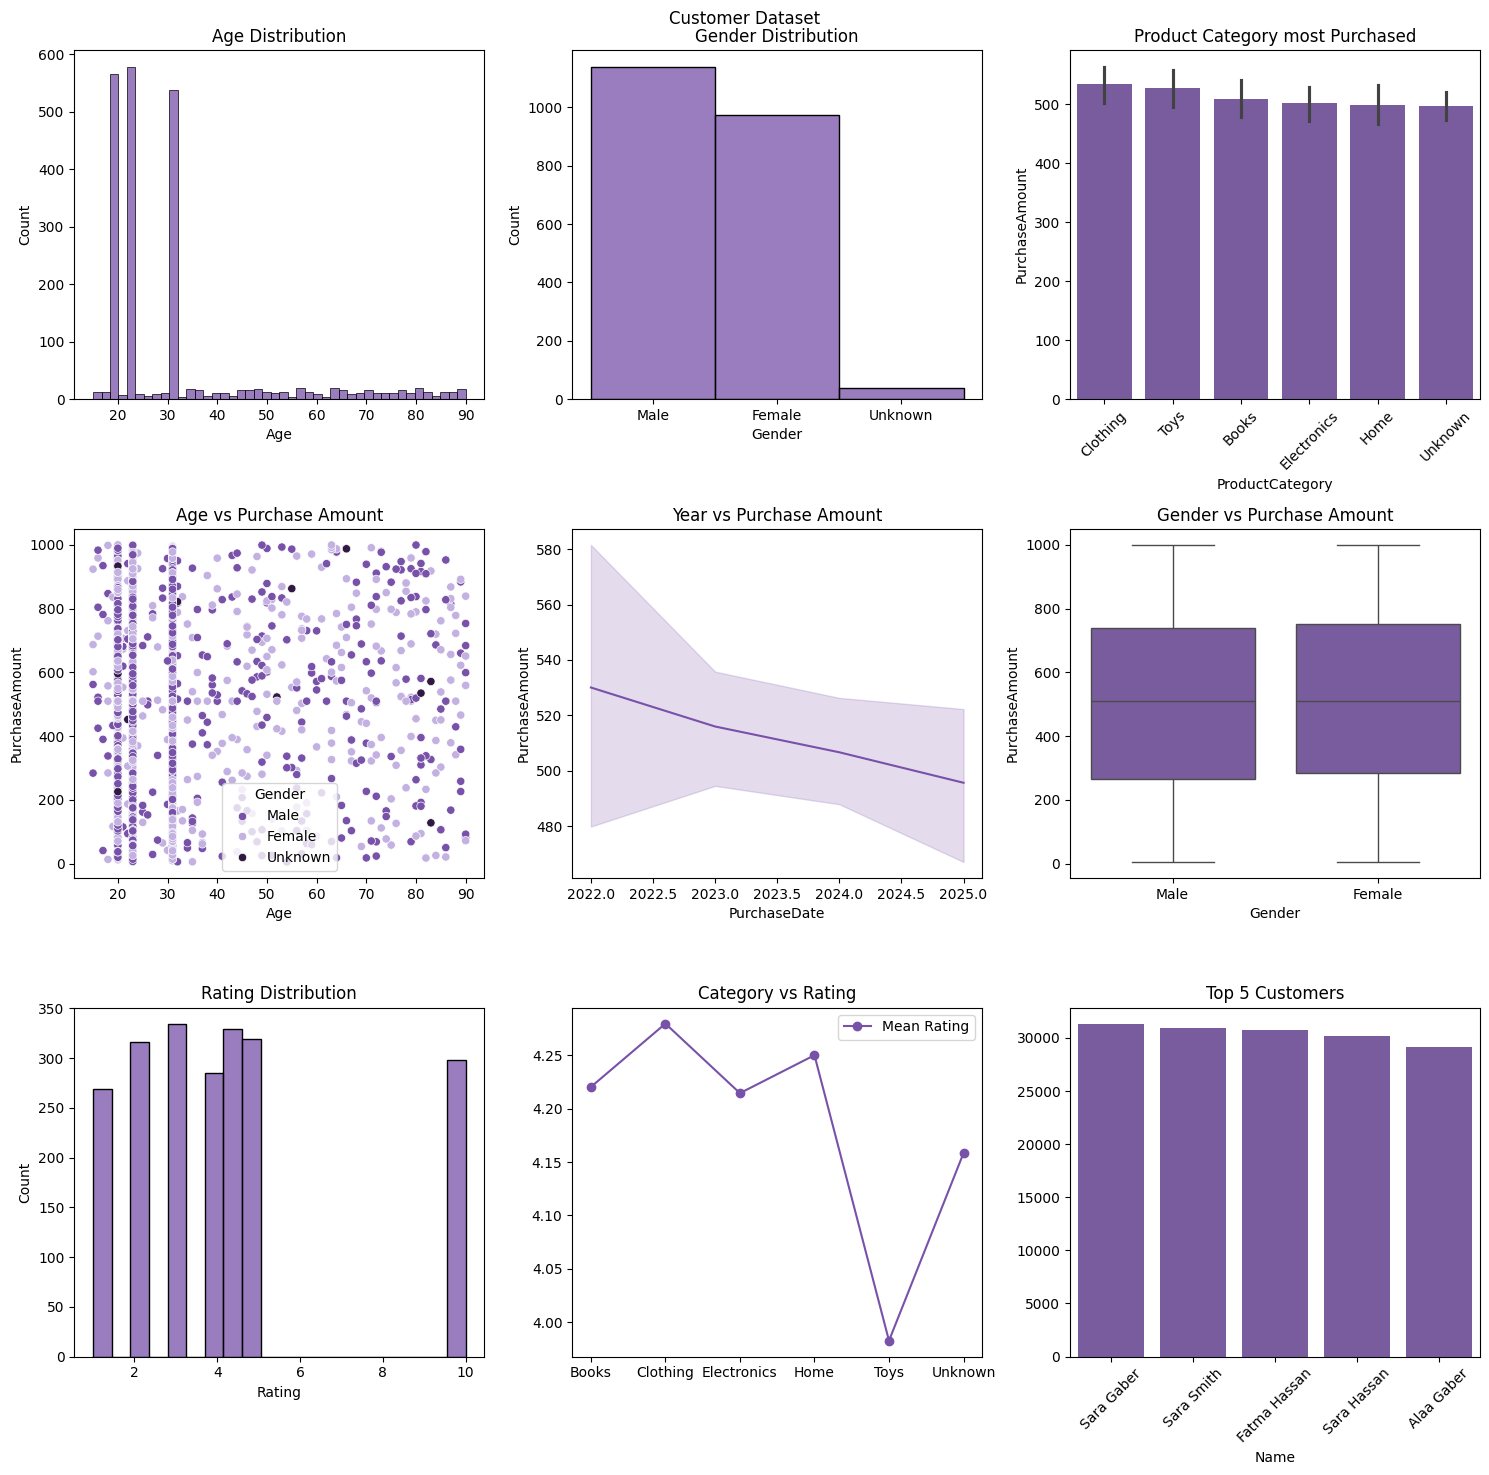

In [36]:
fig, axes = plt.subplots(3,3, figsize=(15,15))
fig.suptitle("Customer Dataset")

# First figure: Age distribution
sns.histplot(df['Age'], ax=axes[0,0])
axes[0,0].set_title("Age Distribution")

# Second figure: Gender distribution
sns.histplot(df['Gender'], ax=axes[0,1])
axes[0,1].set_title("Gender Distribution")

# Third figure: Product Category purchased the most
category_order = df.groupby('ProductCategory')['PurchaseAmount'].mean().sort_values(ascending=False).index

sns.barplot(x='ProductCategory', y='PurchaseAmount', data=df, order=category_order, ax=axes[0,2])
axes[0,2].set_title("Product Category most Purchased")
axes[0,2].tick_params(axis='x', rotation=45)


# Fourth figure: The relation between the age and the purchase amount
sns.scatterplot(x='Age', y='PurchaseAmount', data=df,hue='Gender', ax=axes[1,0])
axes[1,0].set_title("Age vs Purchase Amount")

# Fifth figure: The year having the most purchase amount
sns.lineplot(x=df['PurchaseDate'].dt.year, y='PurchaseAmount', data=df, ax=axes[1,1])
axes[1,1].set_title("Year vs Purchase Amount")


# Sixth figure: Gender vs Purchase Amount
# Filter out 'Unknown' genders
df_gender = df[df['Gender'] != 'Unknown']

sns.boxplot(x='Gender', y='PurchaseAmount', data=df_gender, ax=axes[1,2])
axes[1,2].set_title("Gender vs Purchase Amount")

# Seventh figure: Rating Distribution
sns.histplot(df['Rating'], ax=axes[2,0])
axes[2,0].set_title("Rating Distribution")

# Eighth figure: Category vs Rating as lines
# Compute mean rating per category
category_means = df.groupby('ProductCategory')['Rating'].mean().sort_index()
axes[2,1].plot(category_means.index, category_means.values, marker='o', label='Mean Rating')
axes[2,1].set_title("Category vs Rating")
axes[2,1].legend()

# Nineth figure: Top 5 customers
top_customers = df.groupby('Name')['PurchaseAmount'].sum().sort_values(ascending=False).head(5)
sns.barplot(x=top_customers.index, y=top_customers.values, ax=axes[2,2])
axes[2,2].set_title("Top 5 Customers")
axes[2,2].tick_params(axis='x', rotation=45)

# Adjust the spacing between the graphs
plt.tight_layout()

plt.show()
